In [16]:
import pandas as pd
perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [17]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(perch_full, perch_weight, random_state=42)

In [19]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((42, 3), (14, 3), (42,), (14,))

In [20]:
# PolynomialFeatures 연습
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False) # 절편 항 무시
poly.fit([[2,3]])
poly.transform([[2,3]])

array([[2., 3., 4., 6., 9.]])

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False)
poly.fit(x_train)
x_train_poly = poly.transform(x_train)
x_train_poly.shape

(42, 9)

In [22]:
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

In [23]:
x_test_poly = poly.transform(x_test)
x_test_poly.shape

(14, 9)

In [24]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_poly, y_train)
lr.score(x_train_poly, y_train)

0.9903183436982126

In [25]:
lr.score(x_test_poly, y_test)

0.9714559911594095

In [26]:
poly = PolynomialFeatures(degree=5, include_bias=False)
poly.fit(x_train)
x_train_poly = poly.transform(x_train)
x_test_poly = poly.transform(x_test)
x_train_poly.shape

(42, 55)

In [28]:
lr.fit(x_train_poly, y_train)
lr.score(x_train_poly, y_train)

0.9999999999976599

In [29]:
lr.score(x_test_poly, y_test)

-144.4072001577299

In [30]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(x_train_poly)
x_train_scaled = ss.transform(x_train_poly)
x_test_scaled = ss.transform(x_test_poly)

In [33]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(x_train_scaled, y_train)
ridge.score(x_train_scaled, y_train), ridge.score(x_test_scaled, y_test)

(0.9896101671037343, 0.9790693977615398)

In [36]:
import matplotlib.pyplot as plt
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(x_train_scaled, y_train)
    train_score.append(ridge.score(x_train_scaled, y_train))
    test_score.append(ridge.score(x_test_scaled, y_test))

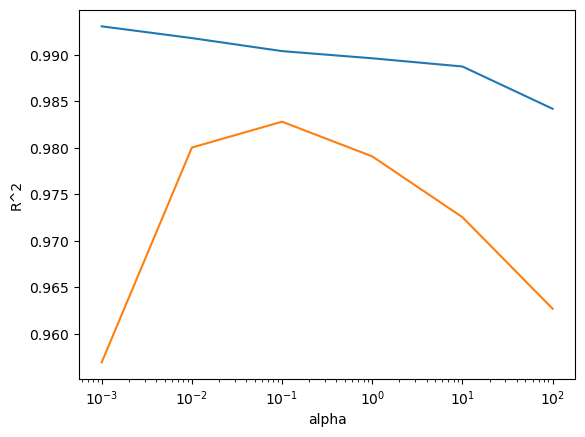

In [37]:
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [41]:
ridge = Ridge(alpha=0.1)
ridge.fit(x_train_scaled, y_train)
ridge.score(x_train_scaled, y_train), ridge.score(x_test_scaled, y_test)

(0.9903815817570367, 0.9827976465387009)

In [ ]:
# 신뢰성이 ....
from sklearn.linear_model import RidgeCV

# 테스트할 후보 지정
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# RidgeCV 로봇 생성 (자동으로 교차검증하며 최적의 값 찾음)
ridge_cv = RidgeCV(alphas=alphas)
ridge_cv.fit(x_train_scaled, y_train)

# 컴퓨터가 찾아낸 가장 적절한 alpha 값 출력
print("최적의 alpha 값은:", ridge_cv.alpha_)

# 최적의 alpha로 계산된 진짜 최종 점수
print("테스트 세트 점수:", ridge_cv.score(x_test_scaled, y_test))

최적의 alpha 값은: 10.0
테스트 세트 점수: 0.9725329582461572


In [50]:
# 라쏘 회귀
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(x_train_scaled, y_train)
lasso.score(x_train_scaled, y_train), lasso.score(x_test_scaled, y_test)

(0.989789897208096, 0.9800593698421884)

c:\Users\pknukdt\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.336e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\pknukdt\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.025e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\pknukdt\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.062e+02, to

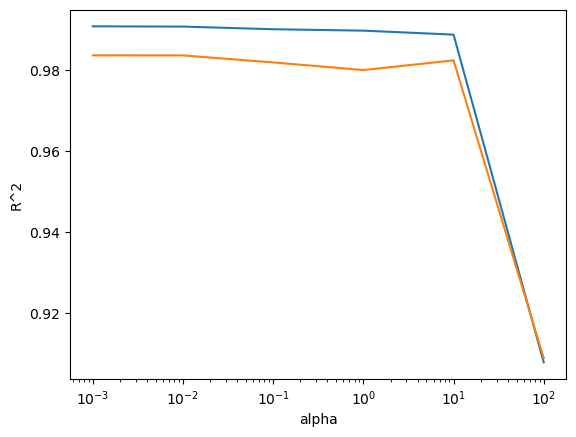

In [51]:
import matplotlib.pyplot as plt
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100] # 후보군
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha)
    lasso.fit(x_train_scaled, y_train)
    train_score.append(lasso.score(x_train_scaled, y_train))
    test_score.append(lasso.score(x_test_scaled, y_test))

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [53]:
lasso = Lasso(alpha=10)
lasso.fit(x_train_scaled, y_train)
lasso.score(x_train_scaled, y_train), lasso.score(x_test_scaled, y_test)

(0.9888067471131867, 0.9824470598706695)

In [55]:
import numpy as np
np.sum(lasso.coef_ == 0)

np.int64(40)

In [56]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)
lr.score(x_train_scaled, y_train), lr.score(x_test_scaled, y_test)

(1.0, -358.8506848122143)